In [1]:
import pandas as pd

df = pd.read_csv('Telco_Churn_dataset.csv')
df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float64
 21  conf

In [4]:
df.columns

Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'cardten', 'voice', 'pager',
       'internet', 'callwait', 'confer', 'ebill', 'loglong', 'logtoll',
       'lninc', 'custcat', 'churn'],
      dtype='str')

In [22]:
binary_cols = ['equip', 'callcard', 'wireless', 'pager', 
               'internet', 'callwait', 'confer', 'ebill', 'voice']

for col in binary_cols:
    df[col] = df[col].astype(int)

df['churn'] = df['churn'].astype(int)
df['ed'] = df['ed'].astype(int)

In [23]:
df.dtypes

tenure      float64
age         float64
address     float64
income      float64
ed            int64
employ      float64
equip         int64
callcard      int64
wireless      int64
longmon     float64
tollmon     float64
equipmon    float64
cardmon     float64
wiremon     float64
longten     float64
tollten     float64
cardten     float64
voice         int64
pager         int64
internet      int64
callwait      int64
confer        int64
ebill         int64
loglong     float64
logtoll     float64
lninc       float64
custcat     float64
churn         int64
dtype: object

In [26]:
df.isnull().sum()

tenure      0
age         0
address     0
income      0
ed          0
employ      0
equip       0
callcard    0
wireless    0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
longten     0
tollten     0
cardten     0
voice       0
pager       0
internet    0
callwait    0
confer      0
ebill       0
loglong     0
logtoll     0
lninc       0
custcat     0
churn       0
dtype: int64

In [27]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['income'] < lower) | (df['income'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 13


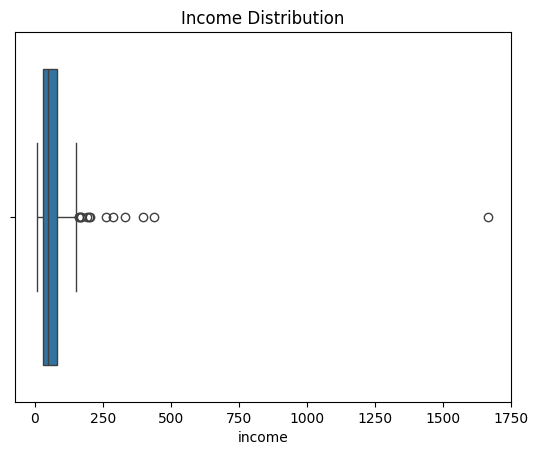

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['income'])
plt.title('Income Distribution')
plt.show()

IQR Formula: lower = Q1 - 1.5 × IQR, upper = Q3 + 1.5 × IQR

In [31]:
pd.get_dummies(df, columns = ['custcat'], dtype = 'int', drop_first = True)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,callwait,confer,ebill,loglong,logtoll,lninc,churn,custcat_2.0,custcat_3.0,custcat_4.0
0,11.0,33.0,7.0,136.0,5,5.0,0,1,1,4.40,...,1,1,0,1.482,3.033,4.913,1,0,0,1
1,33.0,33.0,12.0,33.0,2,0.0,0,0,0,9.45,...,0,0,0,2.246,3.240,3.497,1,0,0,0
2,23.0,30.0,9.0,30.0,1,2.0,0,0,0,6.30,...,0,1,0,1.841,3.240,3.401,0,0,1,0
3,38.0,35.0,5.0,76.0,2,10.0,1,1,1,6.05,...,1,1,1,1.800,3.807,4.331,0,0,0,1
4,7.0,35.0,14.0,80.0,2,15.0,0,1,0,7.10,...,1,1,0,1.960,3.091,4.382,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1,23.0,0,1,0,17.35,...,0,1,0,2.854,3.199,4.419,0,0,1,0
196,34.0,23.0,3.0,24.0,1,7.0,0,1,0,6.00,...,1,1,0,1.792,3.332,3.178,0,0,1,0
197,6.0,32.0,10.0,47.0,1,10.0,0,1,0,3.85,...,1,1,0,1.348,3.168,3.850,0,0,1,0
198,24.0,30.0,0.0,25.0,4,5.0,0,1,1,8.70,...,1,1,1,2.163,3.866,3.219,1,0,0,1


In [38]:
from sklearn.preprocessing import StandardScaler
loat_cols = df.select_dtypes(include=[float]).columns.tolist()
print(float_cols)

['tenure', 'age', 'address', 'income', 'employ', 'longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon', 'longten', 'tollten', 'cardten', 'loglong', 'logtoll', 'lninc', 'custcat']


In [39]:
scaler = StandardScaler()
df[float_cols] = scaler.fit_transform(df[float_cols])

In [40]:
df[['tenure', 'age', 'income']].head()

,tenure,age,income
0,-1.135184,-0.625955,0.475142
1,-0.116043,-0.625955,-0.328861
2,-0.579289,-0.855944,-0.352278
3,0.115580,-0.472629,0.006791
4,-1.320483,-0.472629,0.038015


StandardScaler: only apply to continuous float columns, not binary columns.

In [45]:
service_cols = ['equip', 'callcard', 'wireless', 'voice', 
                'pager', 'internet', 'callwait', 'confer', 'ebill']

df['Total_services'] = df[service_cols].sum(axis = 1)
df['Total_services'].value_counts().sort_index()

Total_services
0    14
1    24
2    30
3    41
4    31
5    16
6     9
7     5
8    13
9    17
Name: count, dtype: int64

In [46]:
df['income_per_tenure'] = df['income'] / (df['tenure'] + 1)

In [47]:
df.to_csv('telco_pipeline_final.csv', index=False)
print("Pipeline complete!")
print(df.shape)

Pipeline complete!
(200, 30)
